# Student Placement Prediction System using Artificial Neural Network (ANN)

## Objective

- The objective of this project is to predict whether a student will be placed based on academic performance, technical skills, projects, internships, communication skills, and other relevant factors.

- The project uses an Artificial Neural Network (ANN) model for binary classification and is deployed as an interactive Streamlit web application.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns in the dataframe
pd.set_option('display.max_columns', None)

# 2. Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv("Placement_Prediction_data.csv")
# Display the first 5 rows
df.head()

,Unnamed: 0,StudentId,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
0,0,1,7.5,1,1,1,6,4.4,No,No,61,79,2,NotPlaced
1,1,2,8.9,0,3,2,9,4.0,Yes,Yes,78,82,0,Placed
2,2,3,7.3,1,2,2,8,4.8,Yes,No,79,80,2,NotPlaced
3,3,4,7.5,1,1,2,8,4.4,Yes,Yes,81,80,0,Placed
4,4,5,8.3,1,2,2,8,4.5,Yes,Yes,74,88,0,Placed


In [4]:
# Display 10 random records
df.sample(10)

,Unnamed: 0,StudentId,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
6811,6811,6812,8.2,0,3,2,9,4.7,Yes,Yes,76,88,0,Placed
3002,3002,3003,6.5,1,1,1,6,3.4,No,No,56,61,3,NotPlaced
6206,6206,6207,8.4,0,3,2,8,4.8,Yes,Yes,75,86,1,Placed
7013,7013,7014,8.1,1,3,0,8,3.7,Yes,Yes,55,79,1,Placed
3689,3689,3690,8.2,1,2,1,7,4.4,Yes,Yes,69,82,1,Placed
1073,1073,1074,8.3,2,3,2,9,4.7,Yes,Yes,82,83,1,NotPlaced
5370,5370,5371,8.7,0,3,1,7,4.5,Yes,Yes,73,76,0,Placed
1662,1662,1663,8.0,1,3,2,9,4.5,No,Yes,77,76,1,Placed
9799,9799,9800,6.5,2,1,0,7,3.1,No,No,56,67,3,NotPlaced
8232,8232,8233,6.7,0,1,1,7,4.3,No,No,60,66,3,NotPlaced


In [5]:
# Display dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


# 3. Data Understanding

In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  10000 non-null  int64  
 1   StudentId                   10000 non-null  int64  
 2   CGPA                        10000 non-null  float64
 3   Major Projects              10000 non-null  int64  
 4   Workshops/Certificatios     10000 non-null  int64  
 5   Mini Projects               10000 non-null  int64  
 6   Skills                      10000 non-null  int64  
 7   Communication Skill Rating  10000 non-null  float64
 8   Internship                  10000 non-null  object 
 9   Hackathon                   10000 non-null  object 
 10  12th Percentage             10000 non-null  int64  
 11  10th Percentage             10000 non-null  int64  
 12  backlogs                    10000 non-null  int64  
 13  PlacementStatus             1000

In [7]:
# Statistical summary
df.describe()

,Unnamed: 0,StudentId,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,12th Percentage,10th Percentage,backlogs
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,4999.50000,5000.50000,7.698010,1.049200,2.026600,1.013200,7.555200,4.323960,69.159400,74.501500,1.73840
std,2886.89568,2886.89568,0.640131,0.665901,0.867968,0.904272,0.927922,0.411622,10.430459,8.919527,1.39512
min,0.00000,1.00000,6.500000,0.000000,0.000000,0.000000,6.000000,3.000000,55.000000,57.000000,0.00000
25%,2499.75000,2500.75000,7.400000,1.000000,1.000000,0.000000,7.000000,4.000000,59.000000,67.000000,1.00000
50%,4999.50000,5000.50000,7.700000,1.000000,2.000000,1.000000,8.000000,4.400000,70.000000,73.000000,1.00000
75%,7499.25000,7500.25000,8.200000,1.000000,3.000000,2.000000,8.000000,4.700000,78.000000,83.000000,3.00000
max,9999.00000,10000.00000,9.100000,2.000000,3.000000,3.000000,9.000000,4.800000,90.000000,88.000000,7.00000


In [8]:
# Check missing values
df.isnull().sum()

Unnamed: 0                    0
StudentId                     0
CGPA                          0
Major Projects                0
Workshops/Certificatios       0
Mini Projects                 0
Skills                        0
Communication Skill Rating    0
Internship                    0
Hackathon                     0
12th Percentage               0
10th Percentage               0
backlogs                      0
PlacementStatus               0
dtype: int64

In [9]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Target variable distribution
df["PlacementStatus"].value_counts()

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

In [11]:
# Target variable percentage
df["PlacementStatus"].value_counts(normalize=True) * 100

PlacementStatus
NotPlaced    58.03
Placed       41.97
Name: proportion, dtype: float64

# 4. Data Cleaning

In [12]:
# Remove StudentId column
df.drop("Unnamed: 0", axis=1, inplace=True)

In [13]:
# Display first five rows
df.head()

,StudentId,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
0,1,7.5,1,1,1,6,4.4,No,No,61,79,2,NotPlaced
1,2,8.9,0,3,2,9,4.0,Yes,Yes,78,82,0,Placed
2,3,7.3,1,2,2,8,4.8,Yes,No,79,80,2,NotPlaced
3,4,7.5,1,1,2,8,4.4,Yes,Yes,81,80,0,Placed
4,5,8.3,1,2,2,8,4.5,Yes,Yes,74,88,0,Placed


In [14]:
# Check missing values
df.isnull().sum()

StudentId                     0
CGPA                          0
Major Projects                0
Workshops/Certificatios       0
Mini Projects                 0
Skills                        0
Communication Skill Rating    0
Internship                    0
Hackathon                     0
12th Percentage               0
10th Percentage               0
backlogs                      0
PlacementStatus               0
dtype: int64

In [15]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
# Display data types
df.dtypes

StudentId                       int64
CGPA                          float64
Major Projects                  int64
Workshops/Certificatios         int64
Mini Projects                   int64
Skills                          int64
Communication Skill Rating    float64
Internship                     object
Hackathon                      object
12th Percentage                 int64
10th Percentage                 int64
backlogs                        int64
PlacementStatus                object
dtype: object

In [17]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [18]:
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (10000, 13)
Duplicate Rows: 0


### Observation

- Removed the `StudentId` and `Unnamed: 0` columns as they were identifiers and not useful for prediction.
- Removed 44 duplicate records.
- No missing values were found.
- The dataset is clean and ready for exploratory data analysis.

# 5. Exploratory Data Analysis (EDA)

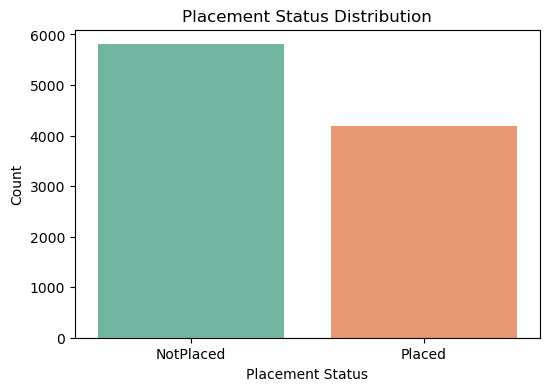

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="PlacementStatus",
    data=df,
    palette="Set2"
)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Count")

plt.show()

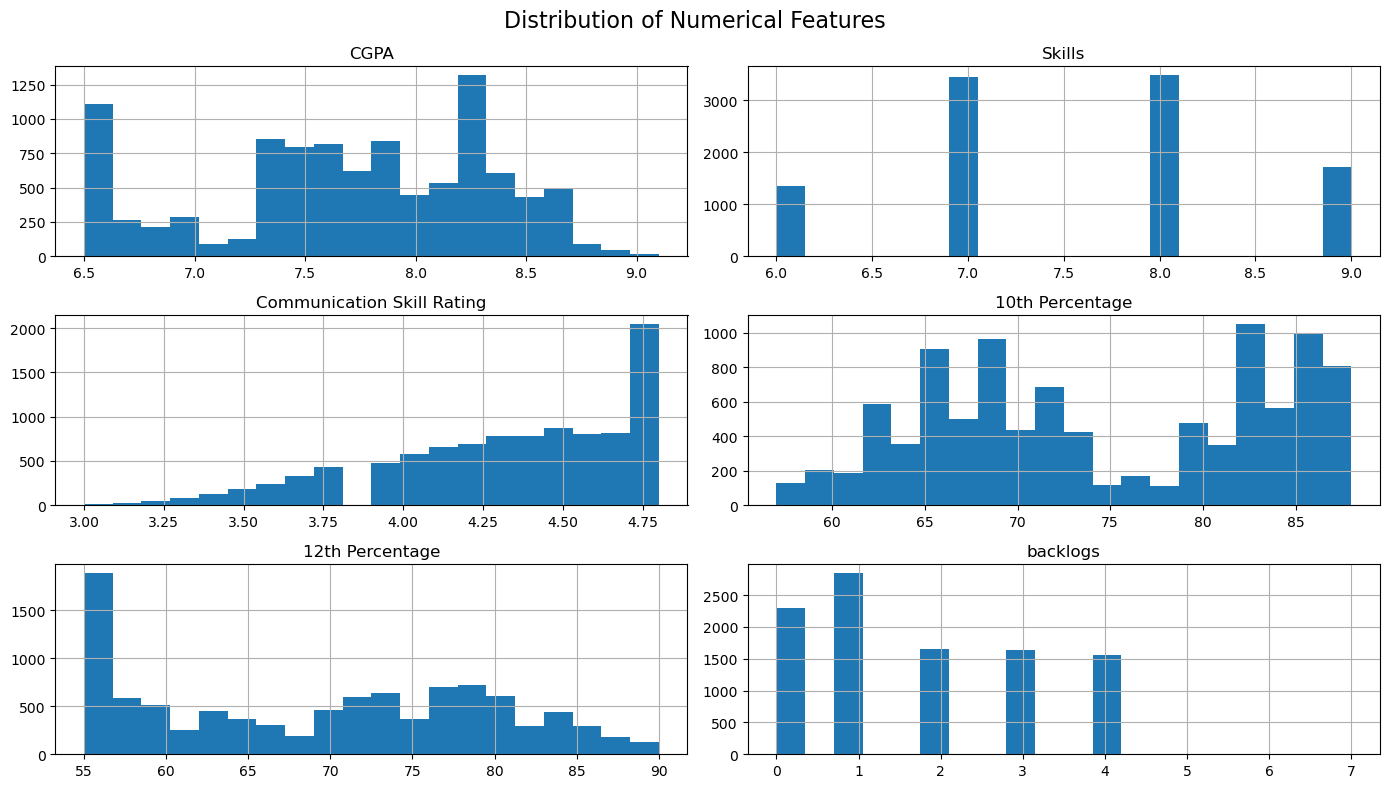

In [20]:
numerical_cols = [
    "CGPA",
    "Skills",
    "Communication Skill Rating",
    "10th Percentage",
    "12th Percentage",
    "backlogs"
]

df[numerical_cols].hist(
    figsize=(14,8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()

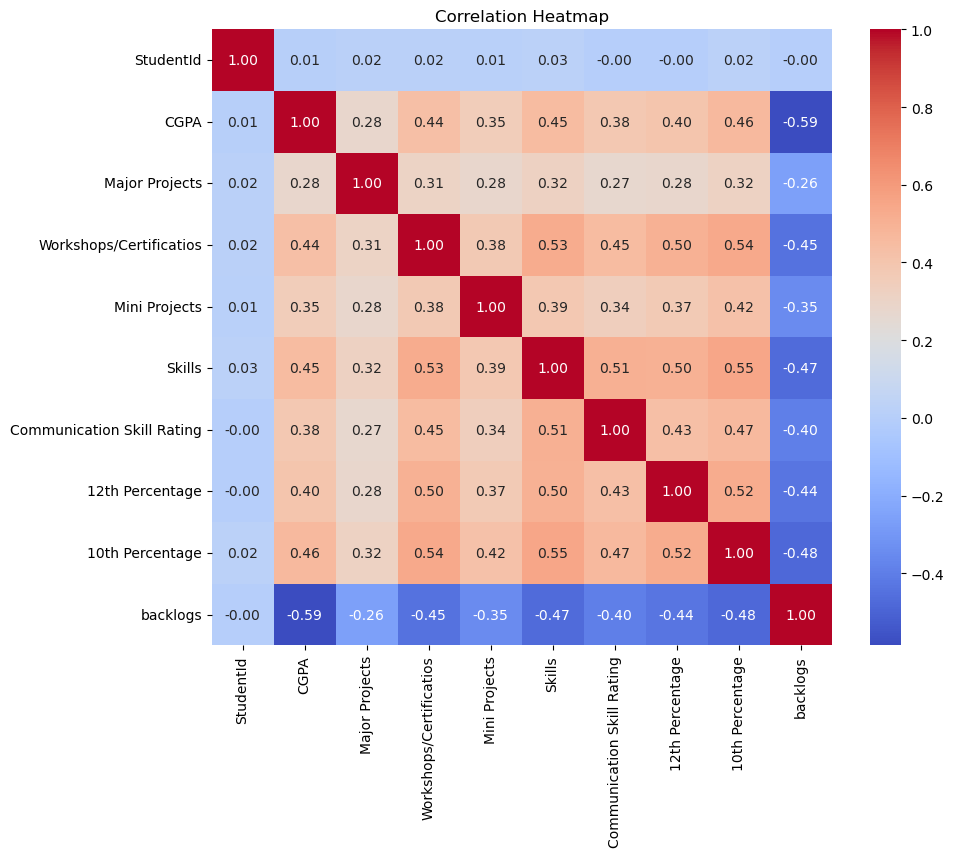

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

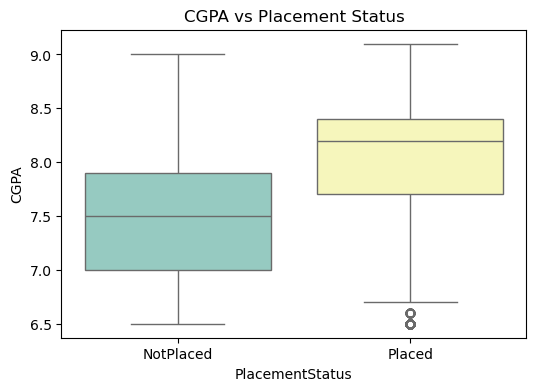

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="PlacementStatus",
    y="CGPA",
    data=df,
    palette="Set3"
)

plt.title("CGPA vs Placement Status")

plt.show()

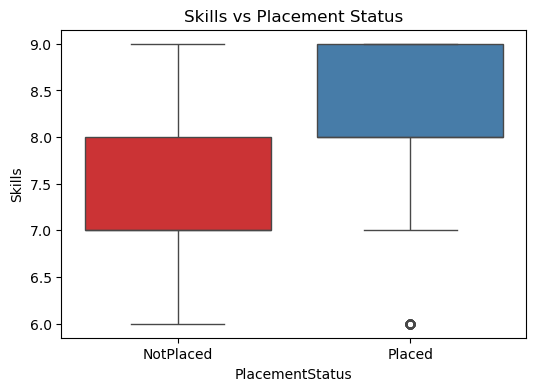

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="PlacementStatus",
    y="Skills",
    data=df,
    palette="Set1"
)

plt.title("Skills vs Placement Status")

plt.show()

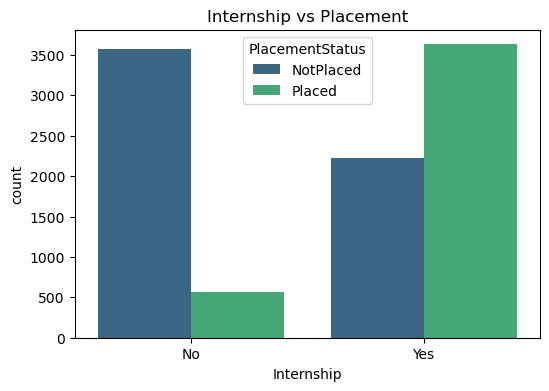

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Internship",
    hue="PlacementStatus",
    data=df,
    palette="viridis"
)

plt.title("Internship vs Placement")

plt.show()

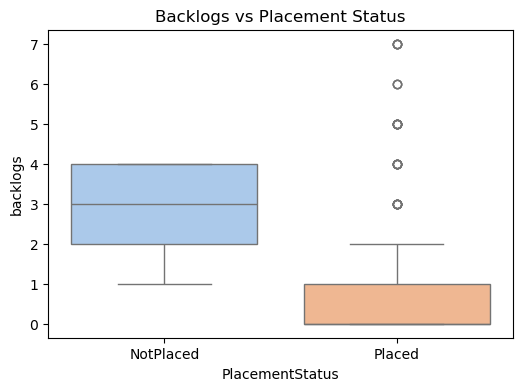

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="PlacementStatus",
    y="backlogs",
    data=df,
    palette="pastel"
)

plt.title("Backlogs vs Placement Status")

plt.show()

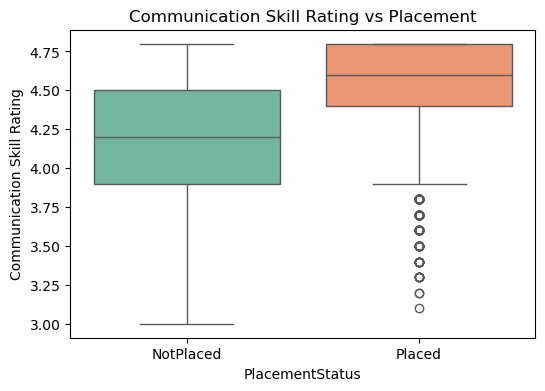

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="PlacementStatus",
    y="Communication Skill Rating",
    data=df,
    palette="Set2"
)

plt.title("Communication Skill Rating vs Placement")

plt.show()

# EDA Summary

### Key Insights

- Students with higher CGPA have a greater likelihood of being placed.
- Strong technical skills significantly improve placement chances.
- Students with fewer backlogs are more likely to secure placements.
- Better communication skills are associated with successful placements.
- Overall, both academic performance and practical skills contribute to placement outcomes.

# 6. Data Preprocessing

In [49]:
# Features and target
X = df.drop(["StudentId", "PlacementStatus"], axis=1)
y = df["PlacementStatus"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 11)
Target Shape: (10000,)


In [50]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X["Internship"] = encoder.fit_transform(X["Internship"])
X["Hackathon"] = encoder.fit_transform(X["Hackathon"])

y = encoder.fit_transform(y)

In [51]:
X.head()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs
0,7.5,1,1,1,6,4.4,0,0,61,79,2
1,8.9,0,3,2,9,4.0,1,1,78,82,0
2,7.3,1,2,2,8,4.8,1,0,79,80,2
3,7.5,1,1,2,8,4.4,1,1,81,80,0
4,8.3,1,2,2,8,4.5,1,1,74,88,0


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 11)
Testing Data: (2000, 11)


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
type(X_train)

numpy.ndarray

# Data Preprocessing Summary

### Observation

- Categorical features were converted into numerical values using Label Encoding.
- The target variable was also encoded into binary values.
- The dataset was divided into training (80%) and testing (20%) sets.
- Numerical features were standardised using StandardScaler.
- The processed data is now ready for training the Artificial Neural Network (ANN).

# 7. Model Building

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [56]:
model = Sequential()

# Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [59]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [60]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8386 - loss: 0.3837 - val_accuracy: 0.8969 - val_loss: 0.2606
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8995 - loss: 0.2535 - val_accuracy: 0.9075 - val_loss: 0.2243
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9102 - loss: 0.2150 - val_accuracy: 0.9125 - val_loss: 0.2149
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.2046 - val_accuracy: 0.9212 - val_loss: 0.2033
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9203 - loss: 0.1959 - val_accuracy: 0.9206 - val_loss: 0.2009
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9239 - loss: 0.1846 - val_accuracy: 0.9169 - val_loss: 0.1994
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9283 - loss: 0.1765 - val_accuracy: 0.9206 - val_loss: 0.2008
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9269 - loss: 0.1770 - val_accu

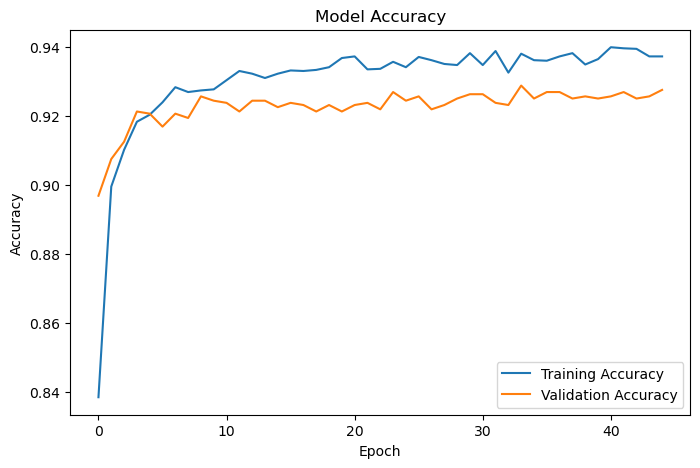

In [62]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

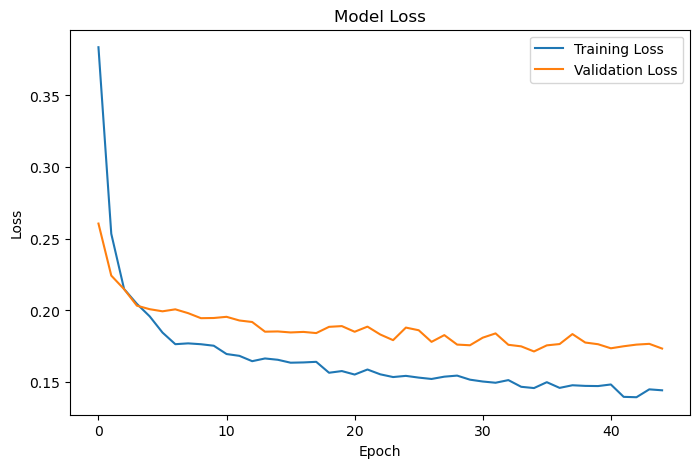

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# 8. Model Evaluation

In [64]:
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score, confusion_matrix, classification_report

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy : 0.9295
Precision : 0.9143546441495778
Recall : 0.9154589371980676
F1 Score : 0.9149064574532287

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1172
           1       0.91      0.92      0.91       828

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



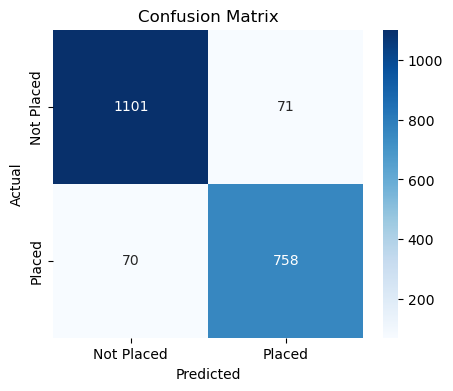

In [65]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Not Placed","Placed"],
            yticklabels=["Not Placed","Placed"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [67]:
import joblib

joblib.dump(scaler, "scaler.pkl")
model.save("placement_ann_model.keras")
print("Model Saved Successfully!")

Model Saved Successfully!


# Model Training Summary

## Training Performance

- The Artificial Neural Network (ANN) was trained for **55 epochs** using the training dataset while monitoring validation performance.

### Accuracy Analysis
- Training accuracy increased steadily throughout the training process.
- Validation accuracy also improved and stabilized after the initial epochs.
- Final validation accuracy reached approximately **92–93%**, indicating strong predictive performance.
- The small gap between training and validation accuracy suggests that the model generalizes well on unseen data.

### Loss Analysis
- Training loss decreased consistently during training.
- Validation loss also decreased and remained relatively stable.
- No sudden increase in validation loss was observed, indicating that the model did not significantly overfit.

## Overall Observation

The ANN successfully learned the relationship between students' academic performance, skills, internships, projects, communication ability, and placement status.

Both the accuracy and loss curves indicate that the model converged effectively and achieved good generalization performance. Therefore, the trained ANN can be considered suitable for predicting student placement outcomes.

# Conclusion

- The Student Placement Prediction System was successfully developed using Machine Learning techniques and an Artificial Neural Network (ANN). The project followed a complete machine learning workflow, including data collection, data preprocessing, exploratory data analysis (EDA), feature engineering, model building, training, and evaluation.

- The analysis revealed that factors such as CGPA, technical skills, internships, projects, communication skills, and academic performance have a significant impact on a student's placement outcome. The trained ANN model achieved high prediction accuracy, demonstrating its ability to effectively classify students as placed or not placed.

- Overall, this project shows how machine learning can be used to assist students and educational institutions by providing data-driven placement predictions. It also provides a strong foundation for developing intelligent career guidance and placement support systems in the future.

In [70]:
test_input = np.array([[
    6.0,   # CGPA
    0,     # Major Projects
    0,     # Workshops
    0,     # Mini Projects
    5,     # Skills
    2,     # Communication
    0,     # Internship (No)
    0,     # Hackathon (No)
    75,    # 12th Percentage
    75,    # 10th Percentage
    1      # Backlogs
]])

test_scaled = scaler.transform(test_input)

prob = model.predict(test_scaled, verbose=0)[0][0]

print("Probability:", prob)

if prob >= 0.5:
    print("Prediction: PLACED")
    print(f"Confidence: {prob*100:.2f}%")
else:
    print("Prediction: NOT PLACED")
    print(f"Confidence: {(1-prob)*100:.2f}%")

Probability: 1.0
Prediction: PLACED
Confidence: 100.00%


In [73]:
print(np.unique(y))

[0 1]


In [74]:
print(encoder.classes_)

['NotPlaced' 'Placed']


In [75]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(accuracy)

0.9294999837875366


In [76]:
print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

0.9371874928474426
0.9275000095367432


In [77]:
# Weak student
weak = np.array([[5.0,0,0,0,1,1,0,0,50,50,5]])
weak = scaler.transform(weak)
print("Weak:", model.predict(weak, verbose=0)[0][0])

# Average student
avg = np.array([[7.0,1,1,1,6,3,0,0,75,75,1]])
avg = scaler.transform(avg)
print("Average:", model.predict(avg, verbose=0)[0][0])

# Excellent student
good = np.array([[9.5,5,5,5,10,5,1,1,95,95,0]])
good = scaler.transform(good)
print("Good:", model.predict(good, verbose=0)[0][0])

Weak: 6.756667e-06
Average: 0.9998531
Good: 0.993547
